## Performance of NMWI


In [3]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import glob, warnings, sys, runpy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")


In [ ]:
# Run when exporting to pdf.
# import matplotlib
# matplotlib.use("cairo")
# import matplotlib.pyplot as plt

In [4]:
# Run only once to get the working directory
project_root = Path("../../").resolve()
os.chdir(project_root)
print("Working dir:", Path.cwd())

Working dir: /Users/barrera.maria/Library/CloudStorage/GoogleDrive-barrera.maria1297@gmail.com/.shortcut-targets-by-id/1LkgWZVWWAMM27iFYdRSBNH8E7w0EPw9j/Maria B/Final_Codes


In [5]:
%matplotlib inline
# METADATA LOADING
vars_dict = runpy.run_path("Codes/Auxiliary_files/Generate_data_index.py")
globals().update(vars_dict)

Found 28 genus tables in index
Removed 4 OTU IDs listed in OTU_IDS_TO_EXCLUDE
Number of samples: 1807, and number of taxa: 294
Number of unique studies: 28

Sample_id per Category:
Category  n_sample_id
    case         1122
 control          685


- X: DataFrame (rows=samples, cols=taxonomy), index includes bioproject/sample_id RELATIVE ABUNDANCE
- y: Series/array-like of True/False (same index as X), True (1) =control, False=case

In [6]:
X_new = X.copy()

In [7]:
%run -i Codes/Auxiliary_files/NMWI.py # Run model

NMWI fitted; 10x10cv


In [8]:
###### RESULTS SUMMARY
print(f"10x10 CV BA: {scores.mean():.4f}") #print(f"10x10 CV SD: {scores.std():.4f}")
print(f"C: {C:.4f}")
print(f"Train ba: {train_bal_acc:.4f}")
print(f"# positive coefs: {num_pos}, # negative coefs: {num_neg}, # zero coefs: {num_zero}")

10x10 CV BA: 0.7382
C: 0.7950
Train ba: 0.7483
# positive coefs: 13, # negative coefs: 10, # zero coefs: 271


## Figure 4.a

In [9]:
# %%writefile Codes/Auxiliary_files/Generate_data_rarefied.py

# Load metadata
file_path_rare = 'Data/Supplementary_table1.xlsx'
df_rare = pd.read_excel(file_path_rare, sheet_name='Index')

def read_genus_table(path):
    with open(path, 'r', encoding='utf-8') as f: 
        lines_rare = f.readlines()

    header_idx_rare = next((i for i,l in enumerate(lines_rare) if l.lstrip().startswith('#OTU ID')), None)
    header_rare = lines_rare[header_idx_rare].lstrip('#').strip().split('\t')
    table_data_rare = pd.read_csv(path, sep='\t', header=None, names=header_rare, skiprows=header_idx_rare+1, dtype=str)

    for c in table_data_rare.columns:
        if c != 'OTU ID': 
            table_data_rare[c] = pd.to_numeric(table_data_rare[c], errors='coerce')
    return table_data_rare

# Esto es lo que hay que cambiar.
paths_rare = sorted(glob.glob(os.path.join('Feature_tables', '**', '*_table_rarefied.tsv'), recursive=True))
allowed_projects_rare = set(df_rare["BioProject.Number"].dropna().astype(str))
filtered_files_rare = [f for f in paths_rare if os.path.basename(f).split("_")[0] in allowed_projects_rare]

print(f"Found {len(filtered_files_rare)} genus tables in index")

# CREATE ALL GENUS TABLES MERGED
merged_rare = None
for p in filtered_files_rare:
    table_data_rare = read_genus_table(p)
    sample_cols_rare = [c for c in table_data_rare.columns if c != 'OTU ID']
    if merged_rare is not None:
        dupes_rare = set(sample_cols_rare) & set([c for c in merged_rare.columns if c != 'OTU ID'])
        if dupes_rare: 
            raise ValueError(f"Duplicate sample IDs found: {dupes_rare} in {p}")
        merged_rare = merged_rare.merge(table_data_rare, on='OTU ID', how='outer')
    else: 
        merged_rare = table_data_rare.copy()

for c in merged_rare.columns:
    if c != 'OTU ID': 
        merged_rare[c] = pd.to_numeric(merged_rare[c], errors='coerce').fillna(0.0)
sample_cols_rare = [c for c in merged_rare.columns if c != 'OTU ID']
merged_rare = merged_rare[['OTU ID'] + sorted(sample_cols_rare)]

merged_rare["OTU ID"] = merged_rare["OTU ID"].apply(simplify_taxonomy)
merged_rare = merged_rare.groupby("OTU ID", as_index=False).sum(numeric_only=True)

ra_sub_rare = merged_rare.set_index('OTU ID').copy() 
ra_sub_initial_rare = ra_sub_rare.copy() # raw abundance

rarefied_merged = ra_sub_initial_rare[keep_samples]
rarefied_t = rarefied_merged.T.reset_index()
rarefied_t.rename(columns={'index': 'Sample_id'}, inplace=True)

rarefied_t = rarefied_t.set_index('Sample_id')
rarefied_t = rarefied_t[taxa_cols].T
m_rarefied = rarefied_t.copy()
m_rarefied.shape


Found 28 genus tables in index


(294, 1807)

In [10]:
# Calculate the others diversity index
from scipy.stats import entropy
shannon2 = m_rarefied.apply(lambda x: entropy(x[x > 0], base=np.e),axis=0)
richness_per_sample = (m_rarefied > 0).sum(axis=0)
simpson = m_rarefied.apply(lambda x: 1 - np.sum((x[x > 0] / x[x > 0].sum())**2),axis=0)

# Combine into one DataFrame
alpha_df = pd.DataFrame({
    "Species Richness": richness_per_sample,
    "Shannon Diversity": shannon2,
    "Simpson Diversity": simpson
})

alpha_df.index.name = "Sample_id"
alpha_df = alpha_df.merge(sra_data, on='Sample_id', how='left')
alpha_df = alpha_df.set_index(['BioProject.Number', 'Sample_id'])

NMWI_scores = pd.DataFrame(scores_all, index=y.index, columns=["NMWI"])
alpha_df = alpha_df.merge(NMWI_scores, on="Sample_id", how="left")

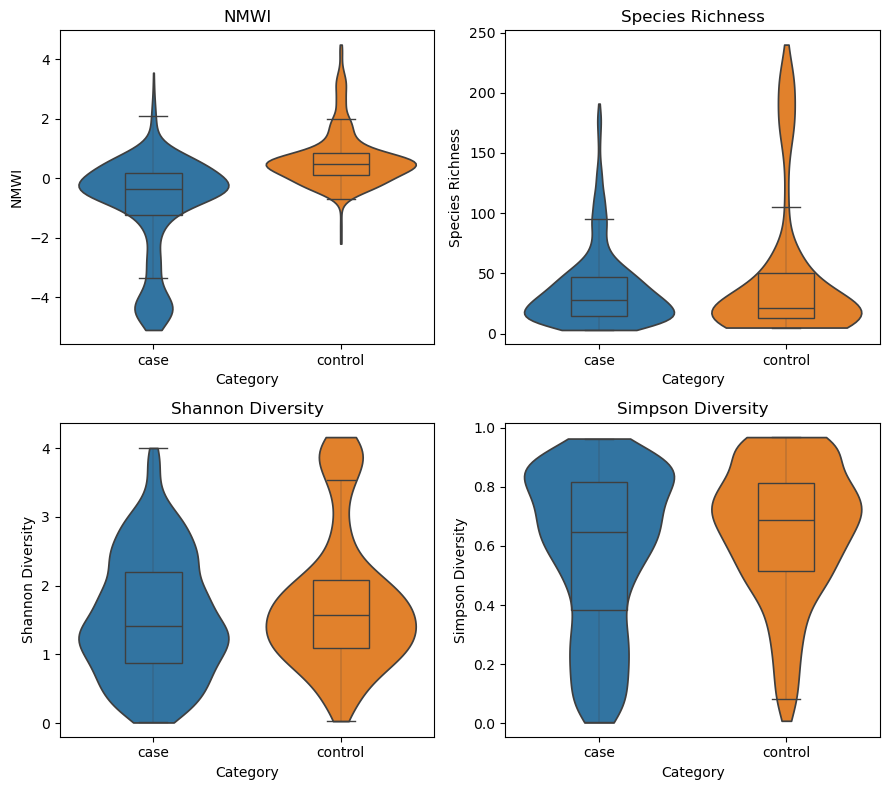

In [11]:
# Violin plots
plot_vars = ["NMWI",
    "Species Richness",
    "Shannon Diversity",
    "Simpson Diversity",
]

plot_df = alpha_df.reset_index().copy()

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
axes = axes.flatten()

for ax, var in zip(axes, plot_vars):
    sns.violinplot(
        data=plot_df,
        x="Category",
        y=var,
        hue="Category",
        # split=True,
        inner=None,
        ax=ax,
        cut = 0
    )
    sns.boxplot(
        data=plot_df,
        x="Category",
        y=var,
        width=0.3,        # 👈 controls box size
        showcaps=True,
        boxprops={'facecolor':'none', 'zorder':3},
        showfliers=False,
        whiskerprops={'linewidth':0.25},
        ax=ax
    )
    ax.set_title(var)
    # ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Figures/Fig4a.pdf')
plt.show()


In [12]:
from scipy.stats import mannwhitneyu

def observeDifference(a, b):
    # Mann-Whitney U test
    u, man_whitney_u_p_val = mannwhitneyu(a, b, alternative="two-sided")
    # Cliff's delta
    cliffs_delta = (2 * u) / (a.shape[0] * b.shape[0]) - 1
    return cliffs_delta, man_whitney_u_p_val

plot_df = alpha_df.reset_index().copy()
results = []
categories = plot_df["Category"].dropna().unique()
cat1, cat2 = categories[0], categories[1]

for metric in plot_vars:
    sub = plot_df[["Category", metric]].dropna()

    a = sub.loc[sub["Category"] == cat1, metric]
    b = sub.loc[sub["Category"] == cat2, metric]

    delta, pval = observeDifference(a, b)

    results.append({
        "Metric": metric,
        "Category_1": cat1,
        "Category_2": cat2,
        "N_1": len(a),
        "N_2": len(b),
        "Cliffs_delta": delta,
        "MannWhitney_p": pval
    })

stats_df = pd.DataFrame(results)
stats_df


,Metric,Category_1,Category_2,N_1,N_2,Cliffs_delta,MannWhitney_p
0,NMWI,case,control,1122,685,-0.638396,4.824628e-115
1,Species Richness,case,control,1122,685,0.067562,1.581756e-02
2,Shannon Diversity,case,control,1122,685,-0.102710,2.446006e-04
3,Simpson Diversity,case,control,1122,685,-0.115526,3.698955e-05


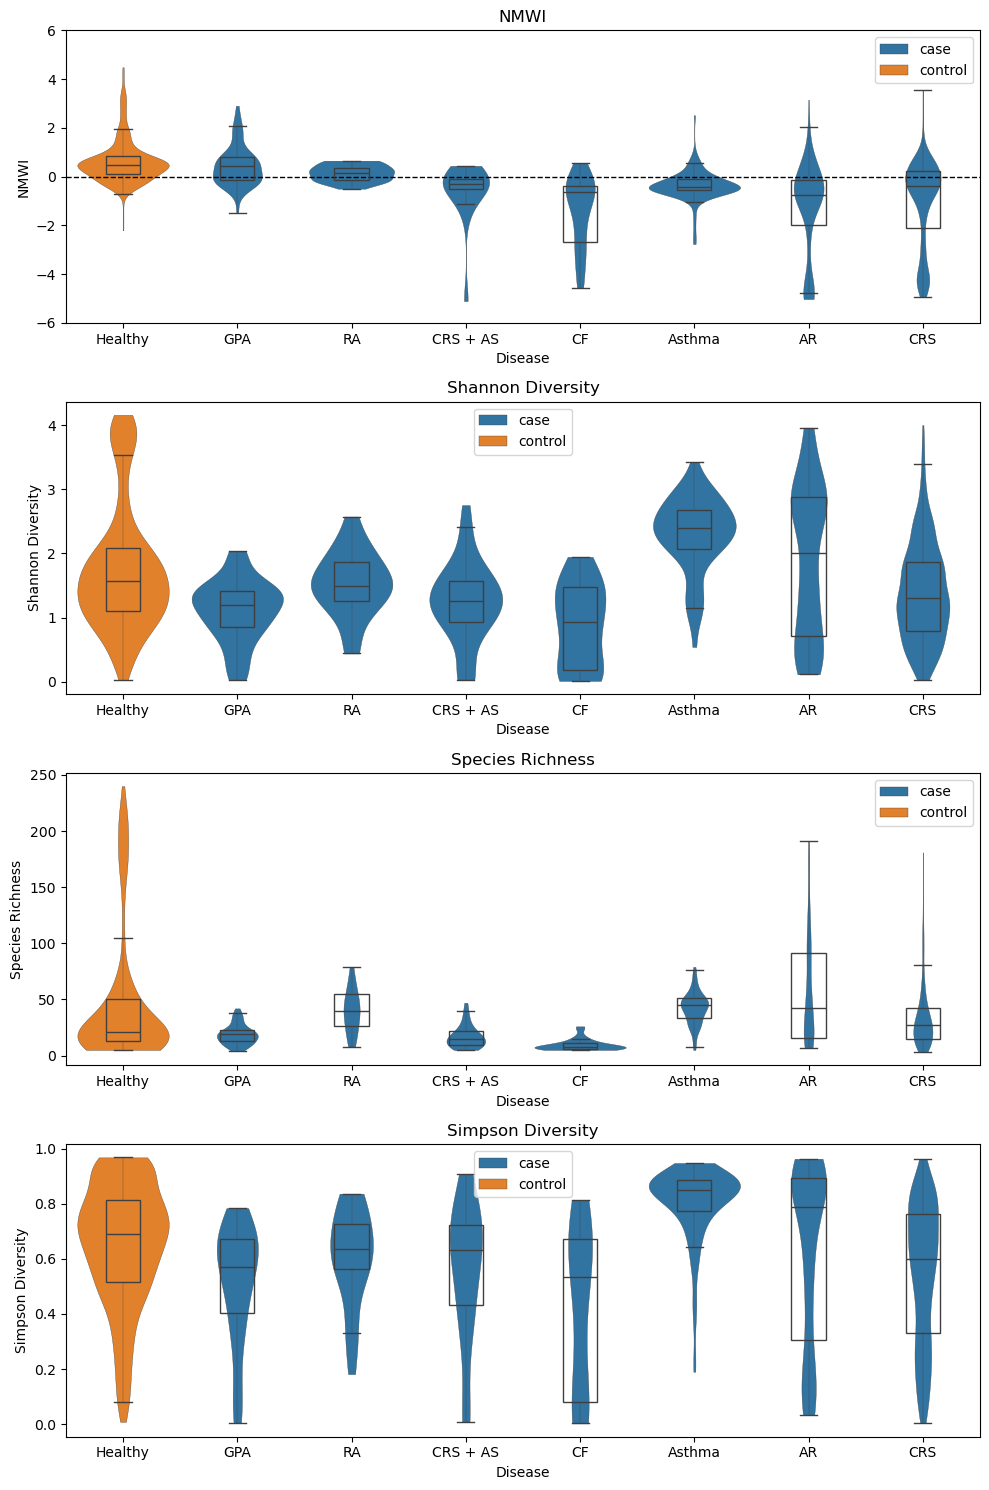

In [17]:
plot_vars = ["NMWI",
    "Shannon Diversity",
    "Species Richness",
    "Simpson Diversity"
]

plot_df = alpha_df.reset_index().copy()
disease_order = ["Healthy"] + nmwi_order
# [d for d in plot_df["Disease"].dropna().unique() if d != "Healthy"]


fig, axes = plt.subplots(4, 1, figsize=(10, 15))
axes = axes.flatten()

for ax, var in zip(axes, plot_vars):
    sns.violinplot(
        data=plot_df,
        x="Disease",
        y=var,
        hue="Category",
        order=disease_order,
        # split=True,
        inner=None,
        ax=ax,
        linewidth=0.25,
        cut = 0
    )
    sns.boxplot(
        data=plot_df,
        x="Disease",
        y=var,
        width=0.3,        # 👈 controls box size
        showcaps=True,
        boxprops={'facecolor':'none', 'zorder':3},
        showfliers=False,
        whiskerprops={'linewidth':0.25},
        ax=ax
    )
    ax.set_title(var)
    # ax.tick_params(axis='x', rotation=45)

axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_ylim(-6,6)
plt.tight_layout()
plt.savefig('Figures/Fig4b.pdf')
plt.show()

In [19]:
from scipy.stats import mannwhitneyu

def observeDifference(a, b):
    u, man_whitney_u_p_val = mannwhitneyu(a, b, alternative="two-sided")
    cliffs_delta = (2 * u) / (a.shape[0] * b.shape[0]) - 1
    return cliffs_delta, man_whitney_u_p_val

plot_vars = ["NMWI", "Shannon Diversity", "Species Richness", "Simpson Diversity"]
plot_df = alpha_df.reset_index().copy()

results = []

healthy_df = plot_df.loc[plot_df["Disease"] == "Healthy"].copy()
diseases = [d for d in plot_df["Disease"].dropna().unique() if d != "Healthy"]

for metric in plot_vars:
    healthy_vals = healthy_df[metric].dropna()

    for disease in diseases:
        disease_vals = plot_df.loc[plot_df["Disease"] == disease, metric].dropna()

        if len(disease_vals) > 0 and len(healthy_vals) > 0:
            delta, pval = observeDifference(disease_vals, healthy_vals)

            results.append({
                "Metric": metric,
                "Disease": disease,
                "Group_1": disease,
                "Group_2": "Healthy",
                "N_1": len(disease_vals),
                "N_2": len(healthy_vals),
                "Cliffs_delta": delta,
                "MannWhitney_p": pval
            })

stats_df = pd.DataFrame(results)
stats_df


,Metric,Disease,Group_1,Group_2,N_1,N_2,Cliffs_delta,MannWhitney_p
0,NMWI,RA,RA,Healthy,21,685,-0.366423,4.206534e-03
1,NMWI,GPA,GPA,Healthy,68,685,-0.120610,1.006633e-01
2,NMWI,CRS + AS,CRS + AS,Healthy,34,685,-0.725719,8.765645e-13
3,NMWI,CRS,CRS,Healthy,653,685,-0.639150,4.953383e-91
4,NMWI,CF,CF,Healthy,30,685,-0.891679,1.299682e-16
5,NMWI,Asthma,Asthma,Healthy,123,685,-0.748549,5.799340e-40
6,NMWI,AR,AR,Healthy,193,685,-0.722915,3.238051e-53
7,Shannon Diversity,RA,RA,Healthy,21,685,-0.042336,7.412359e-01
8,Shannon Diversity,GPA,GPA,Healthy,68,685,-0.407385,2.927671e-08
9,Shannon Diversity,CRS + AS,CRS + AS,Healthy,34,685,-0.287419,4.641162e-03


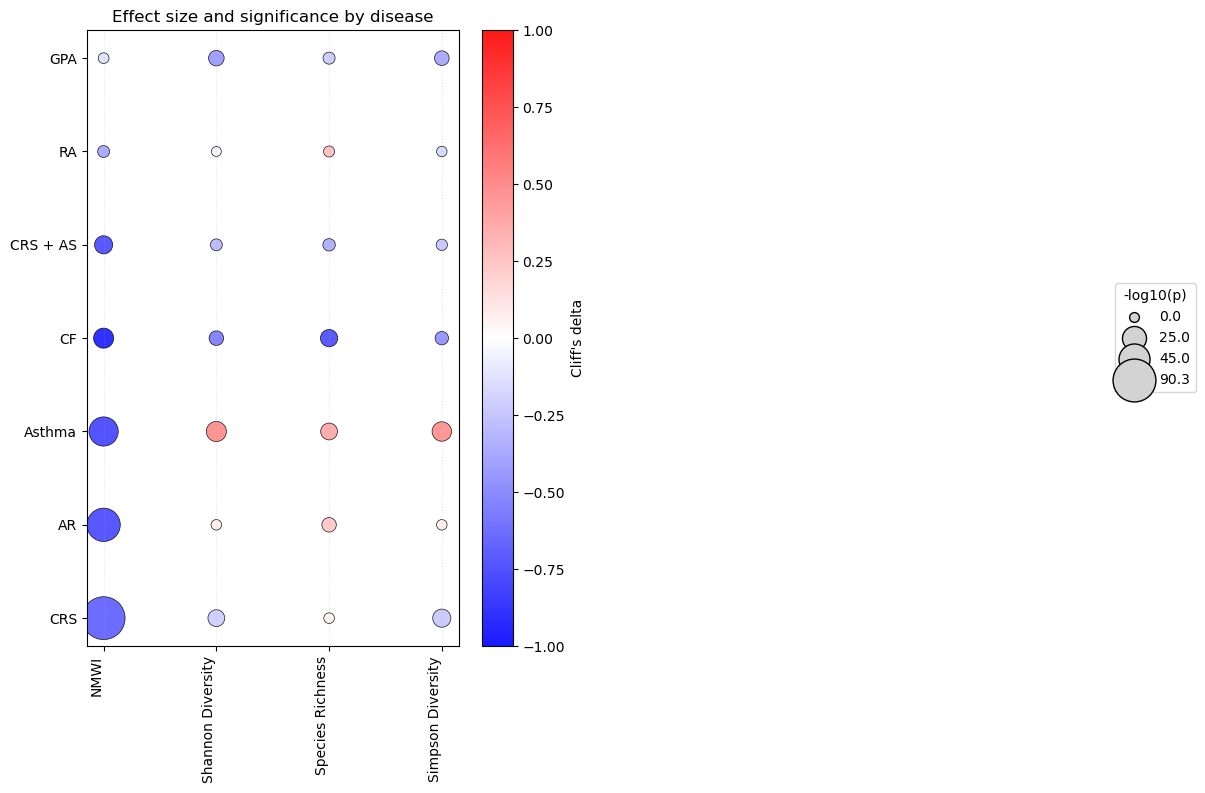

In [20]:
bubble_df = stats_df.copy()
bubble_df["neg_log10_p"] = -np.log10(
    bubble_df["MannWhitney_p"].clip(lower=np.finfo(float).tiny)
)

metric_order = plot_vars if "plot_vars" in globals() else bubble_df["Metric"].tolist()

nmwi_order = (
    bubble_df.loc[bubble_df["Metric"] == "NMWI"]
    .sort_values("MannWhitney_p", ascending=False)["Disease"]
    .tolist()
)

bubble_df["Metric"] = pd.Categorical(
    bubble_df["Metric"],
    categories=metric_order,
    ordered=True
)

bubble_df["Disease"] = pd.Categorical(
    bubble_df["Disease"],
    categories=nmwi_order[::-1],
    ordered=True
)

bubble_df = bubble_df.sort_values(["Disease", "Metric"])


fig, ax = plt.subplots(figsize=(6, 8))
mul = 10
start = 50
scatter = ax.scatter(
    x=bubble_df["Metric"],
    y=bubble_df["Disease"],
    s=start + bubble_df['neg_log10_p']*mul,
    c=bubble_df["Cliffs_delta"],
    cmap="bwr",
    vmin=-1,
    vmax=1,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Cliff's delta")

ax.set_title("Effect size and significance by disease")

size_vals = [start, 300, 500, 953]

handles = [
    plt.scatter([], [], s=s, facecolor="lightgray", edgecolor="black")
    for s in size_vals
]

labels = [f"{(s - start) / mul:.1f}" for s in size_vals]

ax.legend(
    handles,
    labels,
    title="-log10(p)",
    loc="upper right",
    bbox_to_anchor=(3, 0.6)
)

ax.grid(axis="x", linestyle=":", alpha=0.3)
plt.xticks(rotation = 90, ha="right")
plt.tight_layout()
plt.show()